# Low, Kliuchnikov, Schaeffer (LKS) state preparation
$$
\newcommand{\ket}[1]{|#1\rangle}
\newcommand{\bra}[1]{\langle#1|}
\newcommand{\norm}[1]{\left\lVert#1\right\rVert}
$$
Here we take a look at a relatively-efficient state preparation routine introduced in [arXiv:1812.00954](https://arxiv.org/abs/1812.00954) by Guang Hao Low, Vadym Kliuchnikov, and Luke Schaeffer (hence, "LKS" state prep).

As with all state preparation techniques, the goal is the following: given a list of weights $\vec{a} = [a_0, a_1, ..., a_{2^n - 1}]$, prepare the following $n$-qubit state starting from the all-zero state:

$$ \ket{\psi} = \frac{1}{\sqrt{\norm{\vec{a}}_1}}\sum_{i = 0}^{2^n - 1}\sqrt{a_i}\ket{i}$$


## What is special about LKS state prep?
In spirit, this method belongs to a broader class of state preparation routines known as "Grover-Rudolph" style state preparation, in that it makes use of a cascade of so-called "multiplexed rotations", where the angles you use in those rotations are obtained as a function of the list of weights. This style of state preparation is the same one that WBA's naïve state preparation belongs to.

### Multiplexed rotations
What differentiates LKS state preparation from naïve state preparation basically comes down to how multiplexed rotations are implemented. The definition of a multiplexed rotation is the following:


$$U = \sum_{x = 0}^{2^n - 1} \ket{x}\bra{x} \otimes e^{2\pi i \theta_x Y}$$

**In words**: Give me a register encoding index $x$, I will apply a rotation on some other register with angle $\theta_x$ conditioned on that index reg.

Naïvely, decomposing multiplexed rotations looks like this:

![](./images/naive-multiplexor.png)

The above circuit has $M$-many $\big(\lceil \log M \rceil\big)$-controlled rotations. If we were to break this up into Toffolis and rotations, we'd be looking at some $\mathcal{\tilde{O}}\big(M \cdot \lceil \log M \rceil \big)$ gate complexity.

The secret sauce to LKS state prep is that by using data-loaders to instead first load $b$-bit representations of these angles coherently, and then do simple single-control rotations on the target state, we can instead get away with a scaling like $\mathcal{\tilde{O}}\big(M + b \big)$. Assuming $b \approx \log M$, we see that **we go from a multiplicative scaling to an additive scaling**.

## LKS multiplexing in action

The point of a multiplexor is to coherently apply a variety of rotations by angles $\theta_x$, indexed by the $\ket{x}$ register. If you wanted to do this with data-lookup oracles, roughly speaking you'd have three steps:
* load and index the appropriate $\theta_x$ angle (or some $b$-bit approximation of it we'll call $a_x$).
* conditioned on the bits in this $a_x$ register, apply $b$ singly-controlled rotations that'll add up to a rotation by $a_x$.
* uncompute the data-lookup oracle to return the workhorse bits to their original state.

Let's see how these data-loading-type multiplexors look in code. We can do this by invoking the `LKSMultiplexor` `Qubrick` from WBA.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from psiqworkbench import Qubits, QPU
import numpy as np
from workbench_algorithms.utils import gate_efficient_lambda
from psiqworkbench.utils.misc_utils import random_list_vals_n_bit_precision
from workbench_algorithms import (
    SelectNaive,  # Select imports
    SelectOneAnc,
    SawtoothSelect,
    BinaryTreeSelect,
    SwapUp, 
    DataLookupClean,  # QROM imports
    DataLookupDirtyNaive,
    DataLookupDirtyOptimized,
    LKSMultiplexor,  # LKS imports
    LKSStatePrep
)

In [3]:
# generate some random list of n angles b/w 0 and 180
n = 16
random_angles = np.random.uniform(size=n, low=0, high=180)

random_angles

array([100.78400255, 108.40585305,  93.5946824 ,   1.42482301,
       111.62423441,  10.88482977, 108.88968419,  30.58508367,
       137.88340347,  93.85597825, 169.54071559,  22.3490734 ,
        73.06729241, 116.30656262,  55.76556459, 116.51016823])

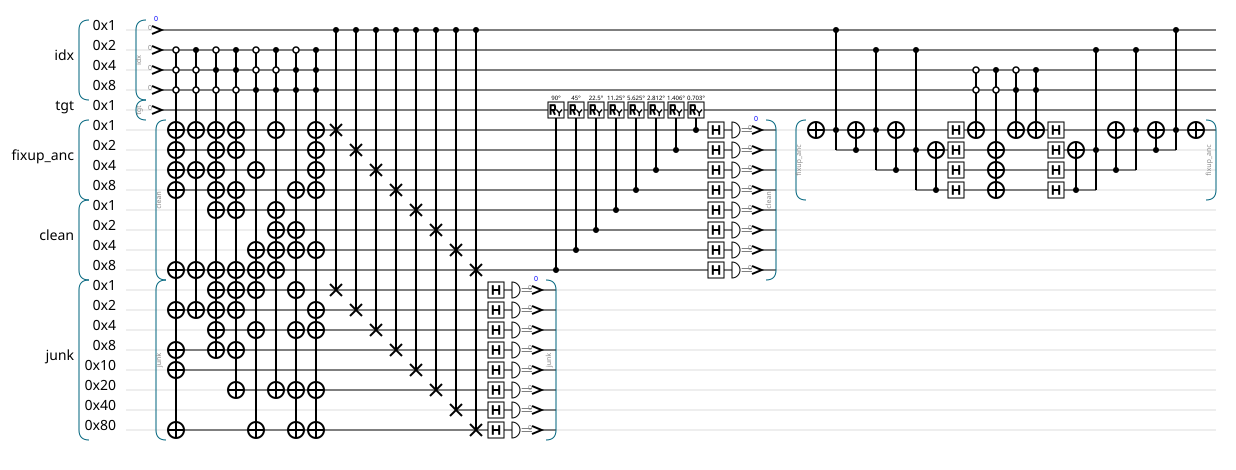

In [4]:
# set up number of qubits for sim
b_of_p = 8  # just choose some bits of precision
lambda_val = 2

num_idx = int(np.ceil(np.log2(len(random_angles))))
num_tgt = 1
num_qrom_anc = b_of_p * lambda_val
num_qubits = num_idx + num_tgt + num_qrom_anc

# set up QPU and Qubits register
qc = QPU()
qc.reset(num_qubits)
idx = Qubits(num_idx, 'idx', qc)
tgt = Qubits(num_tgt, 'tgt', qc)
(idx | tgt).write(0)

# instantiate sub-Qubricks
select = SelectNaive()
swap_up = SwapUp()
qrom = DataLookupClean(select=select, swap_up=swap_up)

# instantiate LKS Multiplexor and call it
lks_mplx = LKSMultiplexor(qrom=qrom, gate=qc.ry)
lks_mplx.compute(idx, tgt, random_angles, b_of_p, lambda_val)

# draw the thing
qc.draw()

### Things to note:
- Indeed, above you can see that first we [load some data using a $\text{QROM}$](Data_loaders_%28QROM%29_tutorial.html), where we load the bit values onto the `b_of_p`-bit register labeled `clean` (and we used `junk` as some extra workhorse qubits), then we apply `b_of_p` single-qubit RY rotations, with each rotation being conditioned on a significant bit of the loaded angle, and then we uncompute the data-loader.
  - **Note**: the data-loader uncomputation notably looks _very_ different from the compute portion; this is because QROMs have a special efficient uncompute.
- The `LKSMultiplexor` takes two arguments at instantiation: a data-loader `Qubrick`, and what type of gate is being multiplexed. In this case (and for state prep), an $\text{RY}$ rotation.
- The `compute` method takes an index register, a target register for the rotations, the list of values we are loading, the bits of precision to represent those values at, and a $\lambda$ value, which is the tunable knob used in QROMs to trade off between gates and qubits. This $\lambda$ defaults to `None`, in which case the Qubrick `will determine the gate-optimal $\lambda$ to use.

I should note that the above multiplexor can take _any_ variation of a data-lookup oracle; we could use dirty $\text{QROMs}$ which borrow already-allocated qubits, the $\text{QROMs}$ themselves can be made up of any number of choices for $\text{SELECT}$, etc. Below I'll execute another LKS multiplexor for the same input angles and bits of precision which makes use of more complex variations of these subroutines:

In [5]:
# set up number of qubits
num_idx = int(np.ceil(np.log2(len(random_angles))))
num_tgt = 1
num_select_anc = num_idx
num_clean_qrom_anc = b_of_p
num_dirty_qrom_anc = b_of_p * (lambda_val - 1)
num_qubits = num_idx + num_tgt + num_clean_qrom_anc + num_dirty_qrom_anc + num_select_anc

In [6]:
# set up QPU and Qubits register
qc = QPU()
qc.reset(num_qubits)
idx = Qubits(num_idx, 'idx', qc)
tgt = Qubits(num_tgt, 'tgt', qc)
dirty = Qubits(num_dirty_qrom_anc, 'dirty', qc)

# set some random state, and then write all qubits except the dirty reg to zero
# this ensures we're starting the dirty reg in some arbitrary state (i.e. truly "dirty")
qc.set_random()
qc.write(0, ~dirty.mask())

In [7]:
# instantiate sub-Qubricks
select = BinaryTreeSelect()
swap_up = SwapUp()
qrom = DataLookupDirtyOptimized(select=select, swap_up=swap_up)

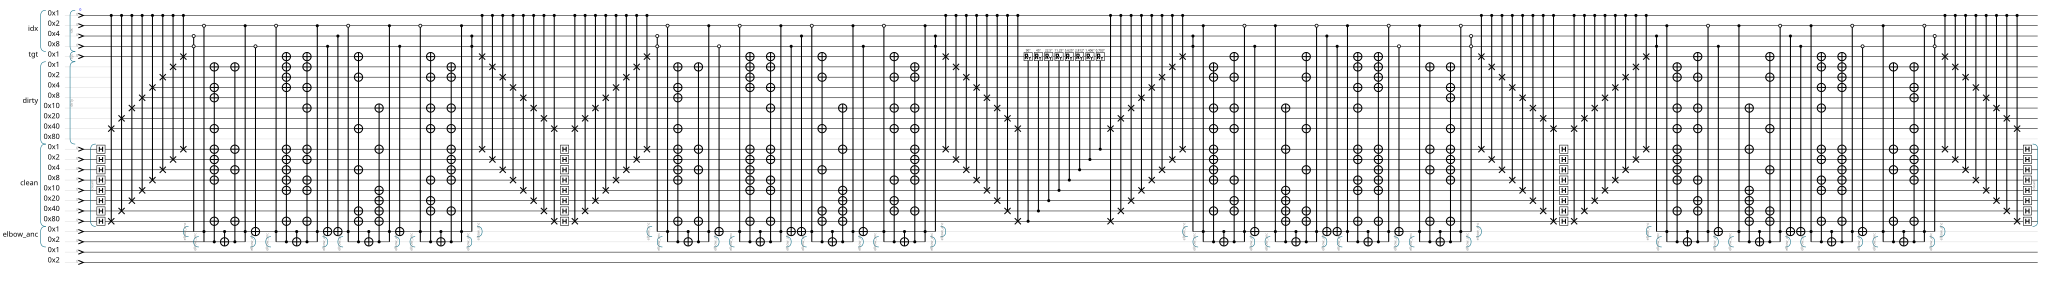

In [8]:
# instantiate LKS Multiplexor and call it
lks_mplx = LKSMultiplexor(qrom=qrom, gate=qc.ry)
lks_mplx.compute(idx, tgt, random_angles, b_of_p, lambda_val)

# draw the thing
qc.draw()

If you zoom in/squint really hard, you should see that despite the circuit looking very different, we're actually still doing the same exact thing: using a $\text{QROM}$ to load some $b$-bit representation of some angles, applying $\text{RY}$ rotations, and then uncomputing the $\text{QROM}$.

## Back to state preparation

So far I've gotten into the magic behind LKS multiplexors; how do we get state prep from this? Well, just as in naïve state preparation, we can prepare some desired state with a cascade of multiplexed $\text{RY}$ rotations:

![](./images/rotations-cascade.png)

All we're going to do differently now is use the LKS multiplexors detailed above every time we see an $\text{RY}$ rotation in the diagram. Let's work through an example using [`LKSStatePrep`](../autoapi/workbench_algorithms/subroutines/lks_state_prep.html#workbench_algorithms.subroutines.lks_state_prep.LKSStatePrep):

In [9]:
# generate a list of random weights
n = 16
weights = np.random.uniform(size=n)
weights

array([0.917894  , 0.67702947, 0.46685167, 0.64515913, 0.00342651,
       0.71205676, 0.60129694, 0.14903555, 0.57940636, 0.59686899,
       0.04277657, 0.50546134, 0.26419574, 0.12679166, 0.44714903,
       0.57466207])

In [10]:
# set up number of qubits for the sim
b_of_p = 10
lambda_val = gate_efficient_lambda(len(weights) // 2, b_of_p)  # only computing here to determine size of the sim

num_prep = int(np.ceil(np.log2(len(weights))))
num_qrom_anc = b_of_p * (lambda_val - 1)
num_qubits = num_prep + num_qrom_anc + b_of_p

In [11]:
# set up QPU instance and Qubits regs
qc = QPU()
qc.reset(num_qubits)
qbits = Qubits(num_prep, 'qbits', qc)

In [12]:
# set up sub-Qubricks
select = SelectNaive()
swap_up = SwapUp()
qrom = DataLookupClean(select=select, swap_up=swap_up)
mplxr = LKSMultiplexor(qrom=qrom, gate=qc.ry)
mplxr_kwargs = {"bits_of_precision": b_of_p}

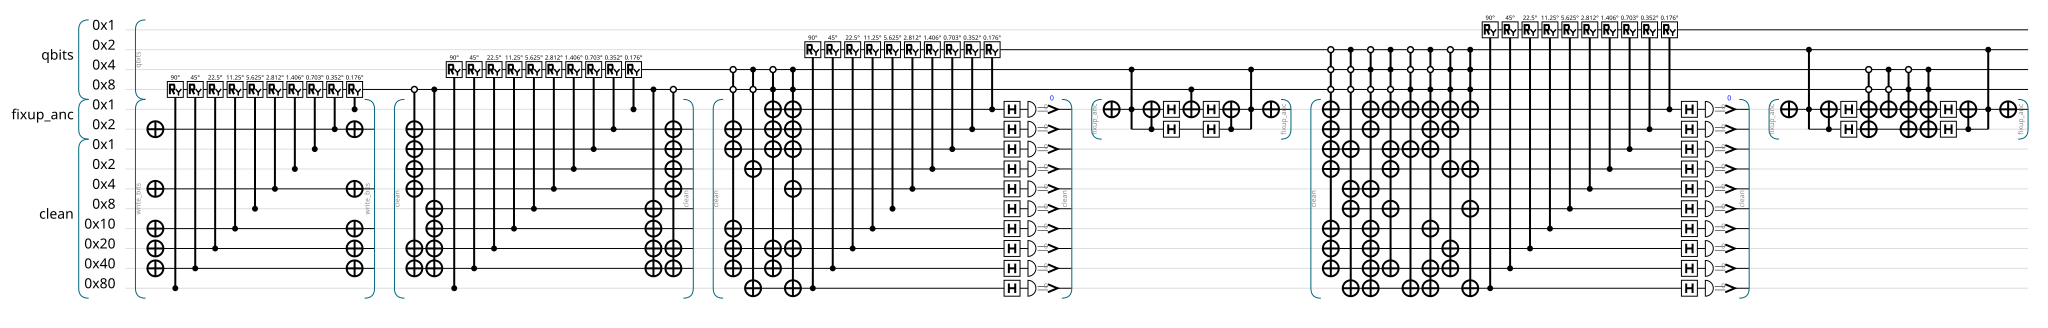

In [13]:
# instantiate state prep routine and execute circuit
lks_prep = LKSStatePrep(weights, mplxr)
lks_prep.compute(qbits, **mplxr_kwargs)

# draw the thing
qc.draw()

We've run the circuit. Now we can compare the resulting probabilities with the expected result. Remember that we are preparing a finite-bit approximation of the weights, thus, we cannot compare directly. Instead, we can calculate the difference between the resulting probabilities and the input weights, and make sure the differences do not violate any known bounds.

In particular, we will make sure the differences per term and the overall absolute difference do not violate the bounds given in Appendix D in the [LKS paper](https://arxiv.org/abs/1812.00954). 

**Per term, we need to satisfy the following:**

$$\vert p_{\text{calculated}, i} - p_{\text{expected}, i}\vert \leq \frac{2 \pi}{b}$$

**For the total difference, we must satisfy:**

$$\sum_{i=0}^{2^n - 1}\vert p_{\text{calculated}, i} - p_{\text{expected}, i}\vert \leq 2^n \cdot \frac{2 \pi}{b}$$

We can grab the resulting probabilities in WB by using the `peek_read_probability` method:

In [14]:
# grab probability of each basis state in the `qbits` register
probs = []
for i in range(len(weights)):
    probs.append(qbits.peek_read_probability(i))

Recall that we load normalized states, so first normalize the weights for the check:

In [15]:
norm = sum(weights)
weights = [weight / norm for weight in weights]

In [16]:
# calculate the differences per term, and the total difference
diffs = [abs(probs[i] - weights[i]) for i in range(len(weights))]
calculated_eps = sum(diffs)

In [17]:
# assert they are within the range given in appendix D
expected_eps_per_term = 2 * np.pi * 2**(-b_of_p)
expected_eps = expected_eps_per_term * len(weights)
for diff in diffs:
    assert diff <= expected_eps_per_term
assert calculated_eps <= expected_eps

You can further convince yourself that this works by printing the resulting state vector (using `qc.print_state_vector()`) and comparing to the (normalized and square-rooted) list of weights; you should find that if you ramp up `b_of_p`, the resulting state vector looks more and more like the processed weights, and likewise, if you crank it down, the state vector should look less and less like the weights.

In [18]:
# print the state on the QPU
qc.print_state_vector()

# print the normalized and square-rooted weights
weights = [np.sqrt(weight) for weight in weights]
weights

|qbits|?>
|0|.>    0.353622+0.000000j
|1|.>    0.304091+0.000000j
|2|.>    0.252918+0.000000j
|3|.>    0.296865+0.000000j
|4|.>    0.021581+0.000000j
|5|.>    0.312134+0.000000j
|6|.>    0.287077+0.000000j
|7|.>    0.142850+0.000000j
|8|.>    0.281307+0.000000j
|9|.>    0.285655+0.000000j
|10|.>    0.076761+0.000000j
|11|.>    0.263189+0.000000j
|12|.>    0.190288+0.000000j
|13|.>    0.131844+0.000000j
|14|.>    0.247587+0.000000j
|15|.>    0.280867+0.000000j


[np.float64(0.3543526963435172),
 np.float64(0.3043289467016751),
 np.float64(0.2527137859943208),
 np.float64(0.29707964637891515),
 np.float64(0.021650372643527174),
 np.float64(0.3121021667053597),
 np.float64(0.2868031858535566),
 np.float64(0.14278560072523133),
 np.float64(0.281534165501249),
 np.float64(0.28574522728150215),
 np.float64(0.07649666055298449),
 np.float64(0.26295621924063073),
 np.float64(0.1901088698886018),
 np.float64(0.13169970982261373),
 np.float64(0.24732363667525917),
 np.float64(0.2803791678667302)]

### (Lots of ) Things to note:
- `LKSStatePrep` takes the weights you wish to load and the multiplexor `Qubrick` you wish to use at instantiation.
- The `compute` method takes the qubits you are preparing the state onto, and a number of [keyword arguments](https://docs.python.org/3/glossary.html#term-argument) that are relevant to the multiplexor (hence, why I call it `mplxr_kwargs`). Keyword arguments are Python `dict`s that take in some number of keys and associated values. In this case, these include:
    - `"bits_of_precision": b_of_p`.
    - `"lambda_val": lambda_val` (this will again default to the gate-efficient value if you do not pass anything).
- Instead of manually setting a `lambda_val`, I am generating one as a function of the number of elements in the list I want to load and the bits of precision I am using to represent the angles via the WBA utility function [`gate_efficient_lambda(num_elements, b_of_p)`](../autoapi/workbench_algorithms/utils/data_lookup_utils.html#workbench_algorithms.utils.data_lookup_utils.gate_efficient_lambda). The reason for this is that each of the QROMs in the cascade of multiplexors used for state prep will have a _different_ optimal value. And in fact, if we choose a `lambda_val` that works for one QROM but is _too big_ for another, then we will get a bit-indexing error. When doing state prep, it is better to default to `None`, in which case each `lambda_val` for each QROM will be computed on-the-fly.

## Final big example

For the sake of completion, below I provide some code that lets you mix and match the various sub-`Qubrick`s that make up `LKSStatePrep` just so you can see some (potentially) wild circuits. **Be warned**: because the various options use very different numbers of qubits, there's a lot of pre-amble to setting up the executable circuit properly.

In [19]:
# choose your SELECT

# select = SelectNaive
# select = SelectOneAnc
select = BinaryTreeSelect
# select = SawtoothSelect

In [20]:
# choose your QROM

qrom = DataLookupClean
# qrom = DataLookupDirtyNaive
# qrom = DataLookupDirtyOptimized

In [21]:
# generate a list of random weights (choose your favorite n, b, and lambda_val)
n = 25
b = 5
weights = np.random.uniform(size=n)
norm = sum(weights)
lambda_val = gate_efficient_lambda(len(weights) // 2, b)

weights

array([0.75460815, 0.04377933, 0.36223154, 0.28301773, 0.67563039,
       0.06483257, 0.99952734, 0.07802122, 0.55308598, 0.75247007,
       0.49643848, 0.6079477 , 0.12378706, 0.09068368, 0.44404876,
       0.34685921, 0.64348159, 0.09332525, 0.02860822, 0.86374721,
       0.9539081 , 0.82657039, 0.23472571, 0.8097898 , 0.11087285])

In [22]:
# set up number of qubits
num_prep = int(np.ceil(np.log2(len(weights))))

if select.__name__ == "SelectOneAnc":
    num_select_anc = 1

elif select.__name__ in ["BinaryTreeSelect", "SawtoothSelect"]:
    num_select_anc = num_prep

elif select.__name__ == "SelectNaive":
    num_select_anc = 0

if qrom.__name__ == "DataLookupDirtyNaive":
    num_dirty = 3 if lambda_val == 1 else b * lambda_val
    num_clean = 0

elif qrom.__name__ == "DataLookupDirtyOptimized":
    num_dirty = 3 if lambda_val == 1 else b * (lambda_val - 1)
    num_clean = 0

else:
    num_dirty = 1
    num_clean = b * (lambda_val - 1)

num_qubits = num_prep + b + num_dirty + num_select_anc + num_clean

In [23]:
# set up QPU instance and qubits
qc = QPU()
qc.reset(num_qubits)
qc.write(0)
qbits = Qubits(num_prep, 'q', qc)
dirty_reg = Qubits(num_dirty, 'dirty', qc)

# set dirty qubits to random init state, write the rest to zero
qc.set_random()
qc.write(0, ~dirty_reg.mask())

In [24]:
# set up sub-Qubricks
swap_up = SwapUp()
select = select()
qrom = qrom(select=select, swap_up=swap_up)
mplxr = LKSMultiplexor(qrom, qc.ry)
mplxr_kwargs = {"bits_of_precision": b}  # do not set a lambda val here as each QROM should choose its own

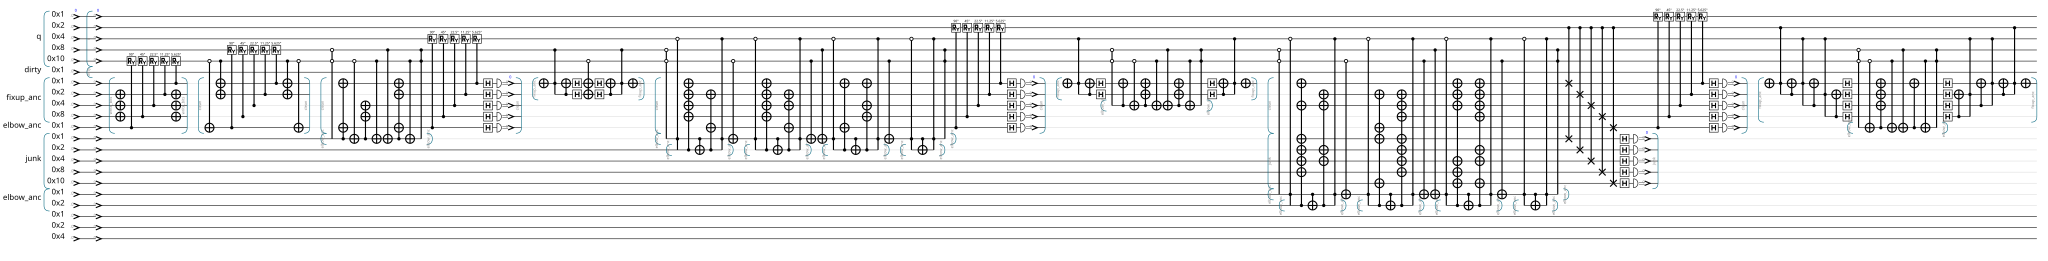

In [25]:
# execute circuit
prep = LKSStatePrep(weights, mplxr)
prep.compute(qbits, **mplxr_kwargs)

# draw the thing
qc.draw()

In [26]:
# process results and compare with expected results
processed_weights = [float(abs(weight)) / norm for weight in weights]

probs = []
for i in range(len(weights)):
    probs.append(qbits.peek_read_probability(i))

diffs = [abs(probs[i] - processed_weights[i]) for i in range(len(processed_weights))]
calculated_eps = sum(diffs)
expected_eps_per_term = 2 * np.pi * 2**(-b)
expected_eps = expected_eps_per_term * len(processed_weights)
for diff in diffs:
    assert diff <= expected_eps_per_term
assert calculated_eps <= expected_eps


for prob, processed_weight in zip(probs, processed_weights):
    print('~~~~~~~~~~~~~~~~~~~~~~~~')
    print('prob: ', prob)
    print('processed weight: ', processed_weight)

~~~~~~~~~~~~~~~~~~~~~~~~
prob:  0.06960807201891592
processed weight:  0.06712402257878317
~~~~~~~~~~~~~~~~~~~~~~~~
prob:  0.004367469187393594
processed weight:  0.0038942662008882817
~~~~~~~~~~~~~~~~~~~~~~~~
prob:  0.033362335101467744
processed weight:  0.03222127703398511
~~~~~~~~~~~~~~~~~~~~~~~~
prob:  0.027405996969294504
processed weight:  0.025175037213822995
~~~~~~~~~~~~~~~~~~~~~~~~
prob:  0.06045145206698492
processed weight:  0.0600987806405739
~~~~~~~~~~~~~~~~~~~~~~~~
prob:  0.005562694890096869
processed weight:  0.0057669973285002655
~~~~~~~~~~~~~~~~~~~~~~~~
prob:  0.08975534434873951
processed weight:  0.08891011266761494
~~~~~~~~~~~~~~~~~~~~~~~~
prob:  0.008259215921139096
processed weight:  0.00694015559437276
~~~~~~~~~~~~~~~~~~~~~~~~
prob:  0.04563833364963555
processed weight:  0.04919819081635018
~~~~~~~~~~~~~~~~~~~~~~~~
prob:  0.06776155430785534
processed weight:  0.0669338360235323
~~~~~~~~~~~~~~~~~~~~~~~~
prob:  0.04201168298335153
processed weight:  0.044159273

## The end
Enjoy!